## 1. Introduction

Dự báo stockout và overstock theo mùa vụ

## 2. Import Libraries & Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [ ]:
# Đường dẫn đến thư mục chứa dữ liệu
RAW_DIR = '../data/raw/'

# Thiết lập style cho biểu đồ
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Đọc dữ liệu
inventory = pd.read_csv(RAW_DIR + 'inventory.csv')
products = pd.read_csv(RAW_DIR + 'products.csv')
promotions = pd.read_csv(RAW_DIR + 'promotions.csv')
web_traffic = pd.read_csv(RAW_DIR + 'web_traffic.csv')

print(f"Inventory shape: {inventory.shape}")
print(f"Products shape: {products.shape}")
print(f"Promotions shape: {promotions.shape}")
print(f"Web traffic shape: {web_traffic.shape}")

Inventory shape: (60247, 17)
Products shape: (2412, 8)
Promotions shape: (50, 10)
Web traffic shape: (3652, 7)
Sales shape: (3833, 3)


## 3. Data Overview

In [7]:
inventory.head()

,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month
0,2022-10-31,1,3,1,1,2,90.0,0.9333,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,10
1,2022-11-30,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,11
2,2022-12-31,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,12
3,2016-04-30,3,35,13,11,2,95.5,0.9333,1,1,0,0.2391,DragonWear MA-03,Casual,All-weather,2016,4
4,2016-05-31,3,36,11,10,1,108.0,0.9667,1,1,0,0.2174,DragonWear MA-03,Casual,All-weather,2016,5


In [8]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60247 entries, 0 to 60246
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   snapshot_date      60247 non-null  datetime64[ns]
 1   product_id         60247 non-null  int64         
 2   stock_on_hand      60247 non-null  int64         
 3   units_received     60247 non-null  int64         
 4   units_sold         60247 non-null  int64         
 5   stockout_days      60247 non-null  int64         
 6   days_of_supply     60247 non-null  float64       
 7   fill_rate          60247 non-null  float64       
 8   stockout_flag      60247 non-null  int64         
 9   overstock_flag     60247 non-null  int64         
 10  reorder_flag       60247 non-null  int64         
 11  sell_through_rate  60247 non-null  float64       
 12  product_name       60247 non-null  object        
 13  category           60247 non-null  object        
 14  segmen

In [9]:
inventory.describe()

,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,year,month
count,60247,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.0,60247.000000,60247.000000,60247.000000
mean,2017-10-08 17:36:29.924809472,1311.408468,189.298455,18.046807,15.417764,1.160639,912.677576,0.961312,0.673411,0.762561,0.0,0.152275,2017.222799,6.617292
min,2012-07-31 00:00:00,1.000000,3.000000,1.000000,1.000000,0.000000,5.200000,0.066700,0.000000,0.000000,0.0,0.000400,2012.000000,1.000000
25%,2015-03-31 00:00:00,760.000000,15.000000,2.000000,2.000000,0.000000,96.000000,0.933300,0.000000,1.000000,0.0,0.042100,2015.000000,4.000000
50%,2017-09-30 00:00:00,1223.000000,62.000000,6.000000,6.000000,1.000000,240.000000,0.966700,1.000000,1.000000,0.0,0.111100,2017.000000,7.000000
75%,2020-04-30 00:00:00,1942.000000,210.000000,19.000000,16.000000,2.000000,683.100000,1.000000,1.000000,1.000000,0.0,0.238100,2020.000000,10.000000
max,2022-12-31 00:00:00,2412.000000,2673.000000,817.000000,670.000000,28.000000,68100.000000,1.000000,1.000000,1.000000,0.0,0.853100,2022.000000,12.000000
std,NaN,673.051769,316.976124,34.080228,28.404379,1.624490,2587.624108,0.054156,0.468969,0.425517,0.0,0.139291,2.972353,3.385629


In [12]:
products.head()

,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406


In [13]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2412 non-null   int64  
 1   product_name  2412 non-null   object 
 2   category      2412 non-null   object 
 3   segment       2412 non-null   object 
 4   size          2412 non-null   object 
 5   color         2412 non-null   object 
 6   price         2412 non-null   float64
 7   cogs          2412 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 150.9+ KB


In [14]:
products.describe()

,product_id,price,cogs
count,2412.000000,2412.000000,2412.000000
mean,1206.500000,4928.216231,3868.346732
std,696.428747,4776.737669,3878.584151
min,1.000000,9.056594,5.183829
25%,603.750000,59.444924,35.066367
50%,1206.500000,4399.605000,3184.934093
75%,1809.250000,7720.513784,5864.916462
max,2412.000000,40950.000000,38902.500000


In [15]:
promotions.head()

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,NaN,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,NaN,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,NaN,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,NaN,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000


In [16]:
promotions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   promo_id             50 non-null     object 
 1   promo_name           50 non-null     object 
 2   promo_type           50 non-null     object 
 3   discount_value       50 non-null     float64
 4   start_date           50 non-null     object 
 5   end_date             50 non-null     object 
 6   applicable_category  10 non-null     object 
 7   promo_channel        50 non-null     object 
 8   stackable_flag       50 non-null     int64  
 9   min_order_value      50 non-null     int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 4.0+ KB


In [17]:
promotions.describe()

,discount_value,stackable_flag,min_order_value
count,50.000000,50.000000,50.000000
mean,18.500000,0.240000,46000.000000
std,11.241777,0.431419,66116.779802
min,10.000000,0.000000,0.000000
25%,12.000000,0.000000,0.000000
50%,16.500000,0.000000,0.000000
75%,20.000000,0.000000,100000.000000
max,50.000000,1.000000,200000.000000


In [18]:
web_traffic.head()

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.00514,102.9,organic_search
1,2013-01-02,10456,8151,47611,0.00406,120.5,organic_search
2,2013-01-03,10076,7458,36963,0.00401,263.6,direct
3,2013-01-04,9973,8063,53078,0.00562,151.8,direct
4,2013-01-05,10223,7882,36790,0.00525,168.6,referral


In [19]:
web_traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      3652 non-null   object 
 1   sessions                  3652 non-null   int64  
 2   unique_visitors           3652 non-null   int64  
 3   page_views                3652 non-null   int64  
 4   bounce_rate               3652 non-null   float64
 5   avg_session_duration_sec  3652 non-null   float64
 6   traffic_source            3652 non-null   object 
dtypes: float64(2), int64(3), object(2)
memory usage: 199.8+ KB


In [20]:
web_traffic.describe()

,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec
count,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000
mean,25041.768072,19031.404436,108615.224535,0.004487,210.283242
std,9422.609335,7237.953062,44472.055524,0.000753,63.771711
min,7973.000000,6136.000000,30451.000000,0.003200,100.100000
25%,17099.250000,12915.000000,72982.000000,0.003848,156.700000
50%,23633.500000,17924.000000,101010.500000,0.004450,209.200000
75%,31782.750000,24191.750000,138086.000000,0.005160,266.200000
max,50947.000000,40430.000000,275560.000000,0.005800,319.900000


## 4. Data Cleaning

 ### 4.1 Clean Inventory

In [22]:
print(f"Số dòng trước khi clean: {len(inventory):,}")


# Chuyển đổi kiểu dữ liệu
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'], errors='coerce')

# Kiểm tra missing values
missing_inv = inventory.isnull().sum()
if missing_inv.sum() > 0:
    print(f"Missing values:")
    print(missing_inv[missing_inv > 0])
else:
    print(f"Không có missing values")

# Xử lý stock_on_hand âm (lỗi logic)
neg_stock = (inventory['stock_on_hand'] < 0).sum()
if neg_stock > 0:
    inventory.loc[inventory['stock_on_hand'] < 0, 'stock_on_hand'] = 0
    print(f"Đã sửa {neg_stock} dòng có stock_on_hand < 0 thành 0")

# Xử lý sell_through_rate ngoài [0,100]
invalid_str = ((inventory['sell_through_rate'] > 100) | (inventory['sell_through_rate'] < 0)).sum()
if invalid_str > 0:
    inventory.loc[inventory['sell_through_rate'] > 100, 'sell_through_rate'] = 100
    inventory.loc[inventory['sell_through_rate'] < 0, 'sell_through_rate'] = 0
    print(f"Đã sửa {invalid_str} dòng có sell_through_rate ngoài [0,100]")

# Xử lý stockout_days > 31 (không thể có trong 1 tháng)
invalid_days = (inventory['stockout_days'] > 31).sum()
if invalid_days > 0:
    inventory.loc[inventory['stockout_days'] > 31, 'stockout_days'] = 31
    print(f"Đã sửa {invalid_days} dòng có stockout_days > 31")

# Xử lý days_of_supply (NaN hoặc vô cùng)
inventory['days_of_supply'] = pd.to_numeric(inventory['days_of_supply'], errors='coerce')
inventory.loc[inventory['days_of_supply'] > 365, 'days_of_supply'] = 365
inventory.loc[inventory['days_of_supply'] < 0, 'days_of_supply'] = 0
days_nan = inventory['days_of_supply'].isna().sum()
if days_nan > 0:
    inventory['days_of_supply'].fillna(inventory['days_of_supply'].median(), inplace=True)
    print(f"Đã điền {days_nan} giá trị days_of_supply bằng median")

# Xóa duplicate (product_id + snapshot_date)
before_dedup = len(inventory)
inventory = inventory.drop_duplicates(subset=['product_id', 'snapshot_date'], keep='last')
after_dedup = len(inventory)
if before_dedup > after_dedup:
    print(f"Đã xóa {before_dedup - after_dedup} dòng duplicate")

print(f"Số dòng sau khi clean: {len(inventory):,}")

Số dòng trước khi clean: 60,247
Không có missing values
Số dòng sau khi clean: 60,247


### 4.2 Clean Products

In [27]:
print(f"Số dòng trước khi clean: {len(products):,}")

# Xử lý missing values trong categorical columns
cat_cols = ['category', 'segment', 'size', 'color']
for col in cat_cols:
    if products[col].isna().sum() > 0:
        products[col].fillna('Unknown', inplace=True)
        print(f"Đã điền 'Unknown' cho {col}")

# Xử lý price âm hoặc bằng 0
neg_price = (products['price'] <= 0).sum()
if neg_price > 0:
    products.loc[products['price'] <= 0, 'price'] = products['price'].median()
    print(f"Đã sửa {neg_price} dòng có price <= 0")

# Kiểm tra ràng buộc cogs < price
invalid_cogs = (products['cogs'] >= products['price']).sum()
if invalid_cogs > 0:
    products.loc[products['cogs'] >= products['price'], 'cogs'] = products['price'] * 0.7
    print(f"Đã sửa {invalid_cogs} dòng có cogs >= price (set = 70% price)")

# Xóa duplicate product_id
products = products.drop_duplicates(subset=['product_id'], keep='first')

print(f"Số dòng sau khi clean: {len(products):,}")

Số dòng trước khi clean: 2,412
Số dòng sau khi clean: 2,412


 ### 4.3 Clean Promotions

In [28]:
print(f"Số dòng trước khi clean: {len(promotions):,}")

# Chuyển đổi ngày tháng
promotions['start_date'] = pd.to_datetime(promotions['start_date'], errors='coerce')
promotions['end_date'] = pd.to_datetime(promotions['end_date'], errors='coerce')

# Xử lý discount_value âm
neg_discount = (promotions['discount_value'] < 0).sum()
if neg_discount > 0:
    promotions.loc[promotions['discount_value'] < 0, 'discount_value'] = 0
    print(f"Đã sửa {neg_discount} dòng có discount_value < 0")

# Xử lý start_date > end_date
invalid_dates = (promotions['start_date'] > promotions['end_date']).sum()
if invalid_dates > 0:
    mask = promotions['start_date'] > promotions['end_date']
    promotions.loc[mask, ['start_date', 'end_date']] = promotions.loc[mask, ['end_date', 'start_date']].values
    print(f"Đã hoán đổi {invalid_dates} dòng có start_date > end_date")

# Xóa các dòng có date null
promotions = promotions.dropna(subset=['start_date', 'end_date'])
print(f"Số dòng sau khi clean: {len(promotions):,}")


Số dòng trước khi clean: 50
Số dòng sau khi clean: 50


### 4.4 Clean Web_Traffic

In [29]:
print(f"Số dòng trước khi clean: {len(web_traffic):,}")

# Chuyển đổi ngày tháng
web_traffic['date'] = pd.to_datetime(web_traffic['date'], errors='coerce')

# Xử lý missing values
if web_traffic['sessions'].isna().sum() > 0:
    web_traffic['sessions'] = web_traffic['sessions'].interpolate(method='linear')
    print(f"Đã interpolate sessions")

if web_traffic['unique_visitors'].isna().sum() > 0:
    web_traffic['unique_visitors'] = web_traffic['unique_visitors'].interpolate(method='linear')

# Xử lý bounce_rate ngoài [0,100]
invalid_bounce = ((web_traffic['bounce_rate'] > 100) | (web_traffic['bounce_rate'] < 0)).sum()
if invalid_bounce > 0:
    web_traffic.loc[web_traffic['bounce_rate'] > 100, 'bounce_rate'] = 100
    web_traffic.loc[web_traffic['bounce_rate'] < 0, 'bounce_rate'] = 0
    print(f"Đã sửa {invalid_bounce} dòng có bounce_rate ngoài [0,100]")

# Xử lý avg_session_duration_sec âm
neg_duration = (web_traffic['avg_session_duration_sec'] < 0).sum()
if neg_duration > 0:
    web_traffic.loc[web_traffic['avg_session_duration_sec'] < 0, 'avg_session_duration_sec'] = 0
    print(f"Đã sửa {neg_duration} dòng có duration âm")

# Xóa dòng có date null
web_traffic = web_traffic.dropna(subset=['date'])

print(f"Số dòng sau khi clean: {len(web_traffic):,}")

Số dòng trước khi clean: 3,652
Số dòng sau khi clean: 3,652


### 4.5 Create Auxiliary Columns For Analysis

In [32]:
# Thêm tháng, năm, quý cho inventory
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
inventory['year'] = inventory['snapshot_date'].dt.year
inventory['month'] = inventory['snapshot_date'].dt.month
inventory['quarter'] = inventory['snapshot_date'].dt.quarter

# Thêm tháng, năm cho web_traffic
web_traffic['year'] = web_traffic['date'].dt.year
web_traffic['month'] = web_traffic['date'].dt.month
web_traffic['day_of_week'] = web_traffic['date'].dt.dayofweek

## 5. Merge Data & Feature Engineering

### 5.1 Merge inventory với products

In [51]:
inventory_full = inventory.merge(products[['product_id', 'category', 'segment', 'product_name', 'price', 'cogs']], 
                                  on='product_id', how='left')
print(f"Số dòng sau merge: {len(inventory_full):,}")
print(f"Số cột sau merge: {len(inventory_full.columns)}")

# Xử lý category sau merge (có thể có 2 cột category_x, category_y do trùng tên)
inventory_full["category"] = inventory_full["category_y"].fillna(inventory_full["category_x"])
inventory_full.drop(columns=["category_x", "category_y"], inplace=True)

# Xử lý product_name sau merge
inventory_full["product_name"] = inventory_full["product_name_y"].fillna(inventory_full["product_name_x"])
inventory_full.drop(columns=["product_name_x", "product_name_y"], inplace=True)

# Xử lý segment sau merge
inventory_full["segment"] = inventory_full["segment_y"].fillna(inventory_full["segment_x"])
inventory_full.drop(columns=["segment_x", "segment_y"], inplace=True)

inventory_full.head()


Số dòng sau merge: 60,247
Số cột sau merge: 23


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,year,month,quarter,price,cogs,category,product_name,segment
0,2022-10-31,1,3,1,1,2,90.0,0.9333,1,0,0,0.2500,2022,10,4,4945.500000,2732.883300,Casual,DragonWear MA-01,All-weather
1,2022-11-30,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,2022,11,4,4945.500000,2732.883300,Casual,DragonWear MA-01,All-weather
2,2022-12-31,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,2022,12,4,4945.500000,2732.883300,Casual,DragonWear MA-01,All-weather
3,2016-04-30,3,35,13,11,2,95.5,0.9333,1,1,0,0.2391,2016,4,2,10831.377188,10289.808329,Casual,DragonWear MA-03,All-weather
4,2016-05-31,3,36,11,10,1,108.0,0.9667,1,1,0,0.2174,2016,5,2,10831.377188,10289.808329,Casual,DragonWear MA-03,All-weather


In [48]:
# Kiểm tra missing values sau merge
missing_cat = inventory_full['category'].isna().sum()
if missing_cat > 0:
    print(f"Có {missing_cat} dòng không có category (gán = 'Unknown')")
    inventory_full['category'].fillna('Unknown', inplace=True)

### 5.2 Create New Features For Analysis 

In [75]:
# Phân loại mức độ rủi ro stockout dựa trên days_of_supply
def get_stockout_risk(day_supply):
    if day_supply < 7:
        return 'CRITICAL'
    elif day_supply < 15:
        return 'HIGH'
    elif day_supply < 30:
        return 'MEDIUM'
    else:
        return 'LOW'

inventory_full['stockout_risk'] = inventory_full['days_of_supply'].apply(get_stockout_risk)

# Phân loại mức độ overstock
def get_overstock_level(overstock_flag, days_supply):
    if overstock_flag == 1:
        if days_supply > 90:
            return 'SEVERE'
        elif days_supply > 60:
            return 'MODERATE'
        else:
            return 'MILD'
    return 'NONE'

inventory_full['overstock_level'] = inventory_full.apply(
    lambda x: get_overstock_level(x['overstock_flag'], x['days_of_supply']), axis=1
)

# Tính gross margin
inventory_full['gross_margin'] = (inventory_full['price'] - inventory_full['cogs']) / inventory_full['price'] * 100

# Giả định: Mỗi ngày stockout mất 30% doanh thu bình thường
inventory_full['daily_avg_sales_units'] = inventory_full['units_sold'] / 30  # 30 ngày/tháng
inventory_full['daily_revenue_normal'] = inventory_full['daily_avg_sales_units'] * inventory_full['price']
inventory_full['potential_loss_stockout'] = (
    inventory_full['stockout_days'] * 
    inventory_full['daily_revenue_normal'] * 
    0.3  # Hệ số thiệt hại (30%)
)

print("\n Thống kê nhanh:")
print(f"- Số sản phẩm duy nhất: {inventory_full['product_id'].nunique():,}")
print(f"- Số danh mục: {inventory_full['category'].nunique()}")
print(f"- Thời gian: {inventory_full['snapshot_date'].min().date()} → {inventory_full['snapshot_date'].max().date()}")

inventory_full.head()


 Thống kê nhanh:
- Số sản phẩm duy nhất: 1,624
- Số danh mục: 4
- Thời gian: 2012-07-31 → 2022-12-31


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,...,cogs,category,product_name,segment,stockout_risk,overstock_level,gross_margin,daily_avg_sales_units,daily_revenue_normal,potential_loss_stockout
0,2022-10-31,1,3,1,1,2,90.0,0.9333,1,0,...,2732.883300,Casual,DragonWear MA-01,All-weather,LOW,NONE,44.74,0.033333,164.850000,98.910000
1,2022-11-30,1,3,1,1,1,90.0,0.9667,1,0,...,2732.883300,Casual,DragonWear MA-01,All-weather,LOW,NONE,44.74,0.033333,164.850000,49.455000
2,2022-12-31,1,3,1,1,1,90.0,0.9667,1,0,...,2732.883300,Casual,DragonWear MA-01,All-weather,LOW,NONE,44.74,0.033333,164.850000,49.455000
3,2016-04-30,3,35,13,11,2,95.5,0.9333,1,1,...,10289.808329,Casual,DragonWear MA-03,All-weather,LOW,SEVERE,5.00,0.366667,3971.504969,2382.902981
4,2016-05-31,3,36,11,10,1,108.0,0.9667,1,1,...,10289.808329,Casual,DragonWear MA-03,All-weather,LOW,SEVERE,5.00,0.333333,3610.459063,1083.137719


## 6. Exploratory Data Analysis (EDA)

### 6.1. Heatmap Stockout

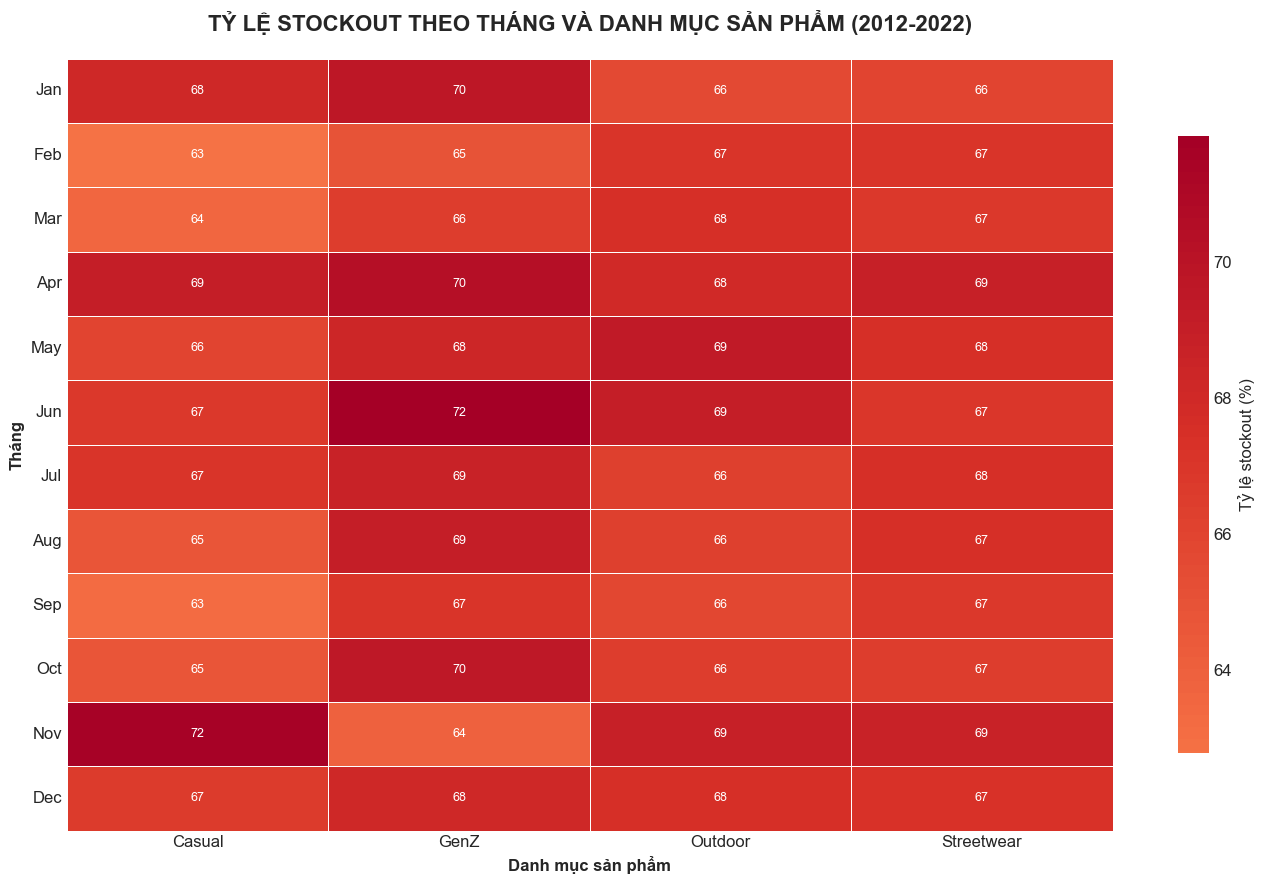


PHÂN TÍCH SỐ LIỆU:

Danh mục stockout cao nhất: GenZ (68.2%)
Danh mục stockout thấp nhất: Casual (66.2%)

Tháng stockout cao nhất: Apr (69.1%)
Tháng stockout thấp nhất: Feb (65.5%)

Thiệt hại ước tính do stockout (2012-2022): 77,205,499


In [76]:
# Tính tỷ lệ stockout
stockout_pivot = inventory_full.groupby(['month', 'category'])['stockout_flag'].mean() * 100
stockout_pivot = stockout_pivot.unstack()

fig, ax = plt.subplots(figsize=(14, 9))

# Tạo heatmap với annotation
heatmap = sns.heatmap(stockout_pivot, 
                      annot=True, 
                      fmt='.0f',
                      cmap='RdYlGn_r',
                      center=50,
                      cbar_kws={'label': 'Tỷ lệ stockout (%)', 'shrink': 0.8},
                      linewidths=0.5,
                      ax=ax,
                      annot_kws={'fontsize': 9})


ax.set_title('TỶ LỆ STOCKOUT THEO THÁNG VÀ DANH MỤC SẢN PHẨM (2012-2022)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Danh mục sản phẩm', fontsize=12, fontweight='bold')
ax.set_ylabel('Tháng', fontsize=12, fontweight='bold')

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_yticklabels(month_names, rotation=0)

plt.tight_layout()
plt.show()

# Phân tích số liệu cụ thể
print("\nPHÂN TÍCH SỐ LIỆU:")

cat_mean = stockout_pivot.mean().sort_values(ascending=False)
print(f"\nDanh mục stockout cao nhất: {cat_mean.index[0]} ({cat_mean.iloc[0]:.1f}%)")
print(f"Danh mục stockout thấp nhất: {cat_mean.index[-1]} ({cat_mean.iloc[-1]:.1f}%)")

month_mean = stockout_pivot.mean(axis=1).sort_values(ascending=False)
print(f"\nTháng stockout cao nhất: {month_names[month_mean.index[0]-1]} ({month_mean.iloc[0]:.1f}%)")
print(f"Tháng stockout thấp nhất: {month_names[month_mean.index[-1]-1]} ({month_mean.iloc[-1]:.1f}%)")

total_loss = inventory_full['potential_loss_stockout'].sum()
print(f"\nThiệt hại ước tính do stockout (2012-2022): {total_loss:,.0f}")

### 6.2. Overstock vs Stockout Paradox

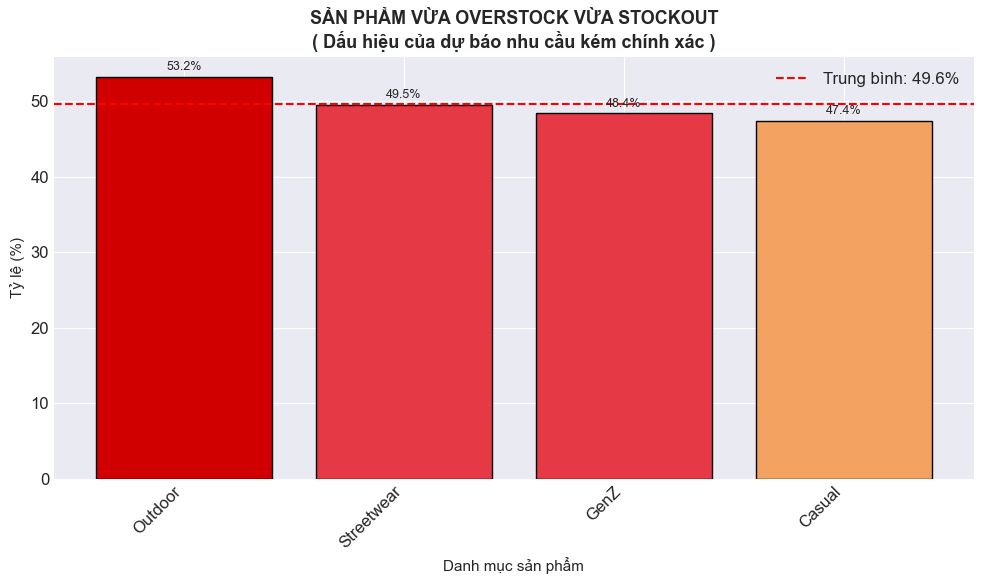

---PHÂN TÍCH---

MÔ TẢ:
Biểu đồ cho thấy tỷ lệ sản phẩm trong mỗi danh mục vừa bị overstock (thừa hàng) 
vừa bị stockout (hết hàng) trong cùng một tháng hoặc các tháng khác nhau.

PHÁT HIỆN CHÍNH:
• Trung bình toàn doanh nghiệp: 49.6% số tháng có nghịch lý
• Danh mục tệ nhất: Outdoor (53.2%)
• Đây là dấu hiệu cho thấy hệ thống dự báo nhu cầu đang hoạt động kém hiệu quả

Ý NGHĨA KINH DOANH:
Doanh nghiệp vừa nhập quá nhiều hàng (overstock) lại vừa để hết hàng (stockout) 
của cùng một sản phẩm → Lãng phí nguồn lực và mất doanh thu.



In [84]:
# Tạo cột paradox
inventory_full['paradox'] = ((inventory_full['overstock_flag'] == 1) & 
                             (inventory_full['stockout_flag'] == 1))

# Tính tỷ lệ paradox theo danh mục
paradox_by_cat = inventory_full.groupby('category')['paradox'].mean() * 100
paradox_by_cat = paradox_by_cat.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

# Vẽ bar chart
colors = ['#d00000' if i == 0 else '#e63946' if i < 3 else '#f4a261' for i in range(len(paradox_by_cat))]
bars = ax.bar(range(len(paradox_by_cat)), paradox_by_cat.values, color=colors, edgecolor='black')

ax.set_xticks(range(len(paradox_by_cat)))
ax.set_xticklabels(paradox_by_cat.index, rotation=45, ha='right')
ax.set_ylabel('Tỷ lệ (%)', fontsize=11)
ax.set_xlabel('Danh mục sản phẩm', fontsize=11)
ax.set_title('SẢN PHẨM VỪA OVERSTOCK VỪA STOCKOUT\n( Dấu hiệu của dự báo nhu cầu kém chính xác )', 
             fontsize=13, fontweight='bold')

# Thêm đường trung bình
avg_line = paradox_by_cat.mean()
ax.axhline(y=avg_line, color='red', linestyle='--', linewidth=1.5, 
           label=f'Trung bình: {avg_line:.1f}%')
ax.legend()

# Thêm số liệu trên cột
for bar, val in zip(bars, paradox_by_cat.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("---PHÂN TÍCH---")

print(f"""
MÔ TẢ:
Biểu đồ cho thấy tỷ lệ sản phẩm trong mỗi danh mục vừa bị overstock (thừa hàng) 
vừa bị stockout (hết hàng) trong cùng một tháng hoặc các tháng khác nhau.

PHÁT HIỆN CHÍNH:
• Trung bình toàn doanh nghiệp: {avg_line:.1f}% số tháng có nghịch lý
• Danh mục tệ nhất: {paradox_by_cat.index[0]} ({paradox_by_cat.iloc[0]:.1f}%)
• Đây là dấu hiệu cho thấy hệ thống dự báo nhu cầu đang hoạt động kém hiệu quả

Ý NGHĨA KINH DOANH:
Doanh nghiệp vừa nhập quá nhiều hàng (overstock) lại vừa để hết hàng (stockout) 
của cùng một sản phẩm → Lãng phí nguồn lực và mất doanh thu.
""")

### 6.3. Predictive Stockout Seasonal Cycle

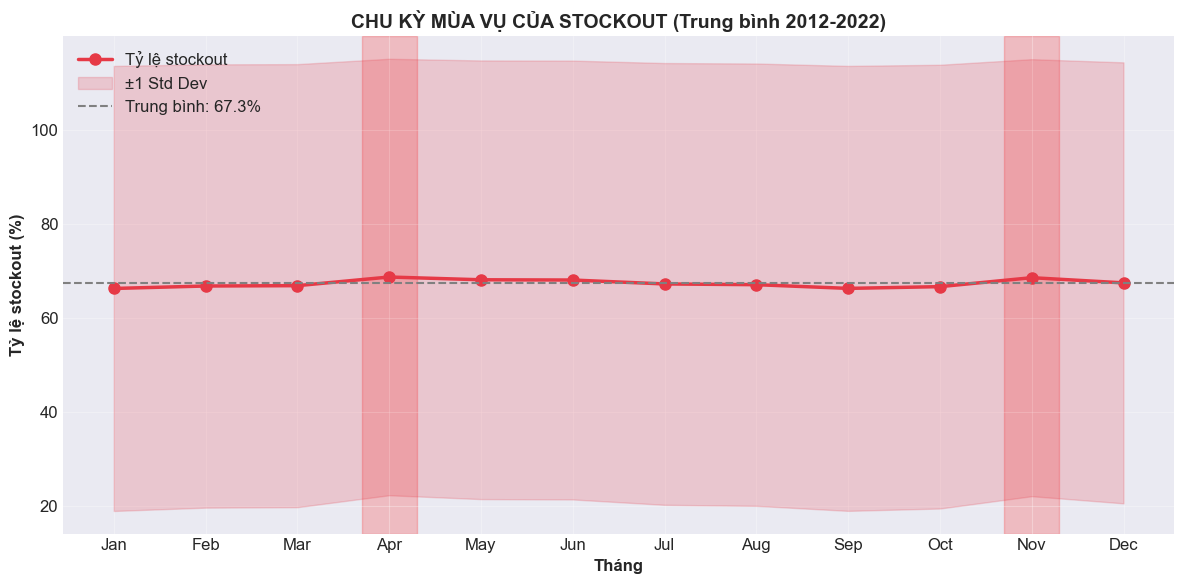

--- PHÂN TÍCH ---
 
MÔ TẢ:
Biểu đồ thể hiện tỷ lệ stockout trung bình theo từng tháng trong năm, 
dựa trên dữ liệu 10 năm (2012-2022).

PHÁT HIỆN CHÍNH:
- Stockout cao nhất vào tháng  4(68.7%) và tháng 11 (68.6%)
- Stockout thấp nhất vào tháng 1-3, 8-10
- Chênh lệch giữa tháng cao nhất và thấp nhất: 2.4%

DỰ BÁO CHO NĂM 2023:
- Dự kiến tháng 4/2023: ~68.7% stockout (±46.4%)
- Dự kiến tháng 11/2023: ~68.6% stockout (±46.4%)

ĐỀ XUẤT HÀNH ĐỘNG:
- Tăng lượng nhập kho từ đầu tháng 3 và đầu tháng 10
- Chuẩn bị kế hoạch dự phòng cho mùa cao điểm



In [92]:
# Tính stockout rate trung bình theo tháng
monthly_stockout = inventory_full.groupby('month')['stockout_flag'].mean() * 100
monthly_std = inventory_full.groupby('month')['stockout_flag'].std() * 100

fig, ax = plt.subplots(figsize=(12, 6))

# Vẽ line chart
months = range(1, 13)
ax.plot(months, monthly_stockout.values, 'o-', linewidth=2.5, markersize=8, 
        color='#e63946', label='Tỷ lệ stockout')

# Thêm vùng biến động (standard deviation)
ax.fill_between(months, 
                monthly_stockout.values - monthly_std.values,
                monthly_stockout.values + monthly_std.values,
                alpha=0.2, color='#e63946', label='±1 Std Dev')

# Đánh dấu các tháng cao điểm
peak_months = [4, 11]
for month in peak_months:
    ax.axvspan(month - 0.3, month + 0.3, alpha=0.2, color='red', zorder=0)

ax.set_xticks(months)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_xlabel('Tháng', fontsize=12, fontweight='bold')
ax.set_ylabel('Tỷ lệ stockout (%)', fontsize=12, fontweight='bold')
ax.set_title('CHU KỲ MÙA VỤ CỦA STOCKOUT (Trung bình 2012-2022)', 
             fontsize=14, fontweight='bold')

# Đường trung bình
avg_line = monthly_stockout.mean()
ax.axhline(y=avg_line, color='gray', linestyle='--', 
           label=f'Trung bình: {avg_line:.1f}%')


ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print("--- PHÂN TÍCH ---")

print(f""" 
MÔ TẢ:
Biểu đồ thể hiện tỷ lệ stockout trung bình theo từng tháng trong năm, 
dựa trên dữ liệu 10 năm (2012-2022).

PHÁT HIỆN CHÍNH:
- Stockout cao nhất vào tháng  4({monthly_stockout.loc[4]:.1f}%) và tháng 11 ({monthly_stockout.loc[11]:.1f}%)
- Stockout thấp nhất vào tháng 1-3, 8-10
- Chênh lệch giữa tháng cao nhất và thấp nhất: {monthly_stockout.max() - monthly_stockout.min():.1f}%

DỰ BÁO CHO NĂM 2023:
- Dự kiến tháng 4/2023: ~{monthly_stockout.loc[4]:.1f}% stockout (±{monthly_std.loc[4]:.1f}%)
- Dự kiến tháng 11/2023: ~{monthly_stockout.loc[11]:.1f}% stockout (±{monthly_std.loc[11]:.1f}%)

ĐỀ XUẤT HÀNH ĐỘNG:
- Tăng lượng nhập kho từ đầu tháng 3 và đầu tháng 10
- Chuẩn bị kế hoạch dự phòng cho mùa cao điểm
""")